In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
import os
from scipy import stats
from sklearn.model_selection import train_test_split

/Users/nadezdasoroko/.pyenv/versions/3.12.11/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
competition_name = "yadro-regression-2025"
download_path = kagglehub.competition_download(competition_name)
print("Файлы сохранены в:", download_path)
print(os.listdir(download_path))

Файлы сохранены в: /Users/nadezdasoroko/.cache/kagglehub/competitions/yadro-regression-2025
['for_prediction.csv', 'train_contest.csv', 'Sample_Submission.csv']


Целевой переменной является значение заработной платы (колонка mean_salary).  
Примечание: в качестве заработной платы обычно указывается некоторый диапазон (от и до). В рассматриваемом файле в качестве значения ЗП (колонка mean_salary) использовано среднее значение такого диапазона.  


train_contest.csv - тренировочный набор данных  
for_prediction.csv - тестовый набор данных  
Sample_Submission.csv - пример файла для отправки (в корректном формате)

# EDA

In [3]:
df = pd.read_csv(f"{download_path}/train_contest.csv")
print(df.shape)
df.head()

(30072, 32)


,premium,name,department,has_test,response_letter_required,area,type,address,response_url,sort_point_distance,...,working_time_intervals,working_time_modes,accept_temporary,description,experience,key_skills,specializations,region,immediate_redirect_url,mean_salary
0,False,Агент по недвижимости,NaN,False,False,"{'id': '2', 'name': 'Санкт-Петербург', 'url': ...","{'id': 'open', 'name': 'Открытая'}","{'city': 'Санкт-Петербург', 'street': 'Невский...",NaN,NaN,...,[],[],False,"<p>Мы ищем людей, которым не достаточно того, ...","{'id': 'noExperience', 'name': 'Нет опыта'}","[{'name': 'Жилая недвижимость'}, {'name': 'Акт...","[{'id': '20.20', 'name': 'Агент', 'profarea_id...",Санкт-Петербург,NaN,125000.0
1,False,IT-специалист/ техник,NaN,False,False,"{'id': '1130', 'name': 'Братск', 'url': 'https...","{'id': 'open', 'name': 'Открытая'}",NaN,NaN,NaN,...,[],[],False,<ul> </ul> <p><em><strong>Навыки</strong></em>...,"{'id': 'between1And3', 'name': 'От 1 года до 3...",[],"[{'id': '1.172', 'name': 'Начальный уровень, М...",Иркутская область,NaN,50000.0
2,False,Старший/ведущий инженер-программист,NaN,False,False,"{'id': '76', 'name': 'Ростов-на-Дону', 'url': ...","{'id': 'open', 'name': 'Открытая'}","{'city': 'Ростов-на-Дону', 'street': '60К-9, 1...",NaN,NaN,...,[],[],False,<strong>Обязанности:</strong> <ul> <li>Разрабо...,"{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'name': 'Linux'}, {'name': 'Bash'}, {'name':...","[{'id': '1.221', 'name': 'Программирование, Ра...",Ростовская область,NaN,80000.0
3,False,Эксперт / методист приемной комиссии,NaN,False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...","{'id': 'open', 'name': 'Открытая'}","{'city': 'Москва', 'street': '1-я Миусская ули...",NaN,NaN,...,[],[],False,<p>Департамент информационных технологий РХТУ ...,"{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'name': '1С программирование'}, {'name': 'Об...","[{'id': '3.150', 'name': 'Менеджмент продукта ...",Москва,NaN,120000.0
4,False,Табельщица/табельщик,NaN,False,False,"{'id': '1613', 'name': 'Энгельс', 'url': 'http...","{'id': 'open', 'name': 'Открытая'}","{'city': None, 'street': None, 'building': Non...",NaN,NaN,...,[],[],False,<p><strong>Обязанности:</strong></p> <ul> <li>...,"{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'name': 'Составление отчетности'}, {'name': ...","[{'id': '18.142', 'name': 'Машиностроение', 'p...",Саратовская область,NaN,15000.0


In [4]:
df = df.drop_duplicates()

In [5]:
df.describe(include="all").T.iloc[:, :-7]

,count,unique,top,freq
premium,30010,2,False,29909
name,30010,13521,Системный администратор,926
department,751,141,"{'id': 'pochta-4352-office', 'name': '«Почта Р...",106
has_test,30010,2,False,29588
response_letter_required,30010,2,False,29517
area,30010,784,"{'id': '1', 'name': 'Москва', 'url': 'https://...",6188
type,30010,2,"{'id': 'open', 'name': 'Открытая'}",29963
address,19065,12811,"{'city': 'Сочи', 'street': 'микрорайон Централ...",121
response_url,0.0,NaN,NaN,NaN
sort_point_distance,0.0,NaN,NaN,NaN


### Анализ целевой переменной (mean_salary)

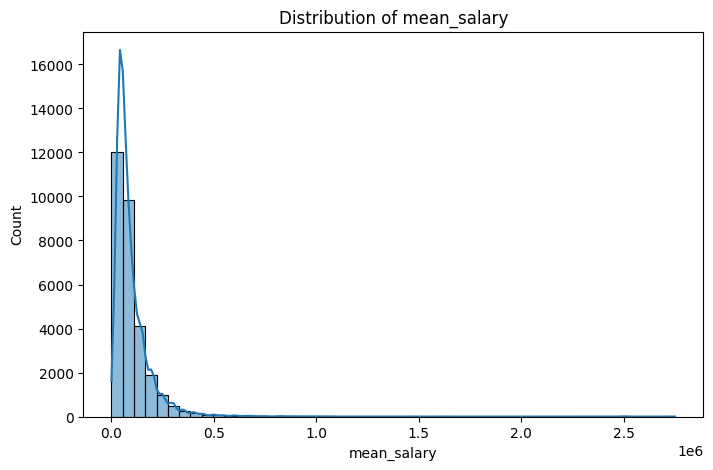

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df['mean_salary'], bins=50, kde=True)
plt.title("Distribution of mean_salary")
plt.show()

In [7]:
# Асимметрия и эксцесс
skew = stats.skew(df['mean_salary'])
kurt = stats.kurtosis(df['mean_salary'])

print(f"Skewness: {skew}")
print(f"Kurtosis: {kurt}")

Skewness: 7.38201764891423
Kurtosis: 119.51349856142052


Следовательно, в целевой переменной наблюдается правая ассиметрия и тяжелый хвост

MAE  будет страдать от сильных выбросов в mean_salary, т.к. она взвешивает ошибки линейно. 
Можно использовать логарифмическое преобразование для сжатия масштаба, а после предсказания обратно преобразовать.

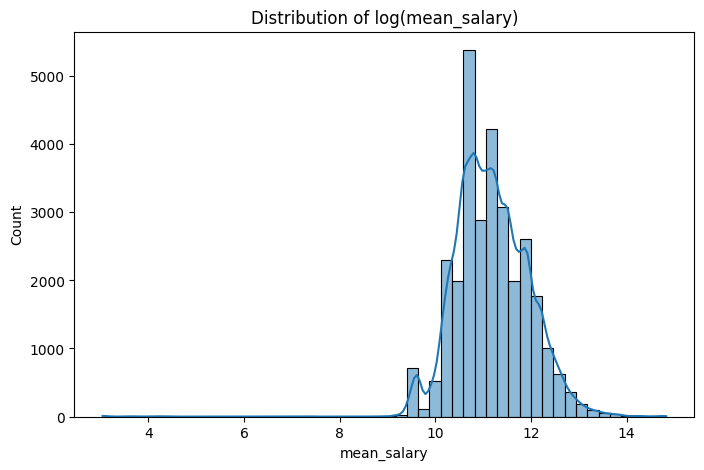

Skew after log: -0.3618077175306792


In [8]:
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df['mean_salary']), bins=50, kde=True)
plt.title("Distribution of log(mean_salary)")
plt.show()

print("Skew after log:", stats.skew(np.log1p(df['mean_salary'])))

Логарифмирование приближает распределение к симметрии. 

In [9]:
Q1 = df['mean_salary'].quantile(0.25)
Q3 = df['mean_salary'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

print("Upper bound (IQR method):", upper_bound)
print("Max salary:", df['mean_salary'].max())

Upper bound (IQR method): 236250.0
Max salary: 2750000.0


Обработка выбросов

{'whiskers': [<matplotlib.lines.Line2D at 0x30583ffe0>,
 'caps': [<matplotlib.lines.Line2D at 0x305864470>,
 'boxes': [<matplotlib.lines.Line2D at 0x30583d760>],
 'medians': [<matplotlib.lines.Line2D at 0x305864a10>],
 'fliers': [<matplotlib.lines.Line2D at 0x305864ce0>],
 'means': []}

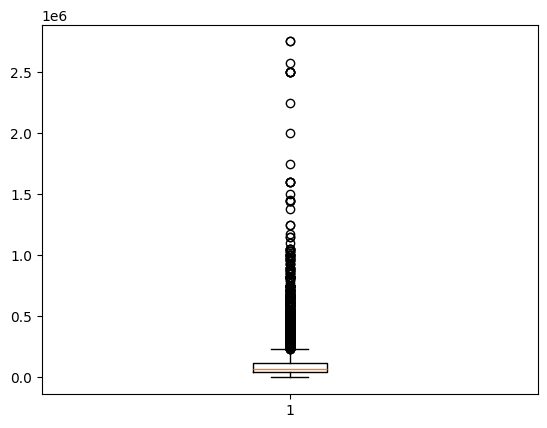

In [10]:
plt.boxplot(df['mean_salary'])

{'whiskers': [<matplotlib.lines.Line2D at 0x3058f71a0>,
 'caps': [<matplotlib.lines.Line2D at 0x3058f7590>,
 'boxes': [<matplotlib.lines.Line2D at 0x3058f6e70>],
 'medians': [<matplotlib.lines.Line2D at 0x3058f7bc0>],
 'fliers': [<matplotlib.lines.Line2D at 0x3058f7ec0>],
 'means': []}

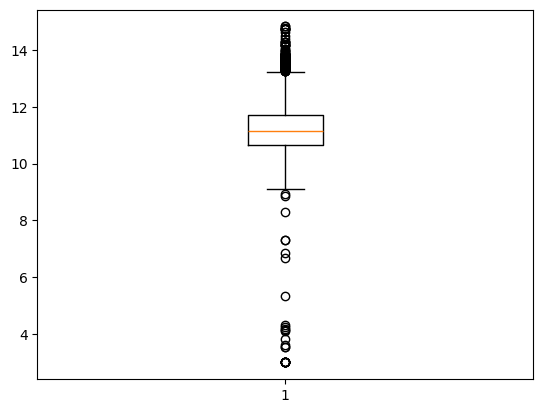

In [11]:
plt.boxplot(df['mean_salary'].apply(lambda x: np.log(x)))

In [12]:
df.loc[df['mean_salary'].eq(df['mean_salary'].max())]

,premium,name,department,has_test,response_letter_required,area,type,address,response_url,sort_point_distance,...,working_time_intervals,working_time_modes,accept_temporary,description,experience,key_skills,specializations,region,immediate_redirect_url,mean_salary
8025,False,Эксперт по элитной недвижимости в Красной Поляне,NaN,False,False,"{'id': '2805', 'name': 'Красная Поляна', 'url'...","{'id': 'open', 'name': 'Открытая'}",NaN,NaN,NaN,...,[],[],False,<strong>Обязанности:</strong> <ul> <li>Сопрово...,"{'id': 'between3And6', 'name': 'От 3 до 6 лет'}","[{'name': 'Грамотная речь'}, {'name': 'Ведение...","[{'id': '17.242', 'name': 'Прямые продажи', 'p...",Краснодарский край,NaN,2750000.0
27640,False,Эксперт по недвижимости в Красной Поляне,NaN,False,False,"{'id': '2805', 'name': 'Красная Поляна', 'url'...","{'id': 'open', 'name': 'Открытая'}",NaN,NaN,NaN,...,[],[],False,<strong>Обязанности:</strong> <ul> <li>Сопрово...,"{'id': 'between3And6', 'name': 'От 3 до 6 лет'}","[{'name': 'Грамотная речь'}, {'name': 'Ведение...","[{'id': '17.242', 'name': 'Прямые продажи', 'p...",Краснодарский край,NaN,2750000.0


Логарифм применим позже.  
Ограничение по диапазону зарплат ухудшает результат. 

### Анализ пропусков

In [13]:
df = df.replace('[]', np.nan)
missing = df.isna().mean().sort_values(ascending=False)
missing[missing > 0]

/var/folders/3z/h7_y2tw90bd9_d3j8sfghz_00000gn/T/ipykernel_7136/2285183806.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace('[]', np.nan)


relations                 1.000000
immediate_redirect_url    1.000000
response_url              1.000000
sort_point_distance       1.000000
insider_interview         0.996868
working_days              0.993369
working_time_modes        0.980573
department                0.974975
working_time_intervals    0.965645
contacts                  0.365012
address                   0.364712
key_skills                0.173309
dtype: float64

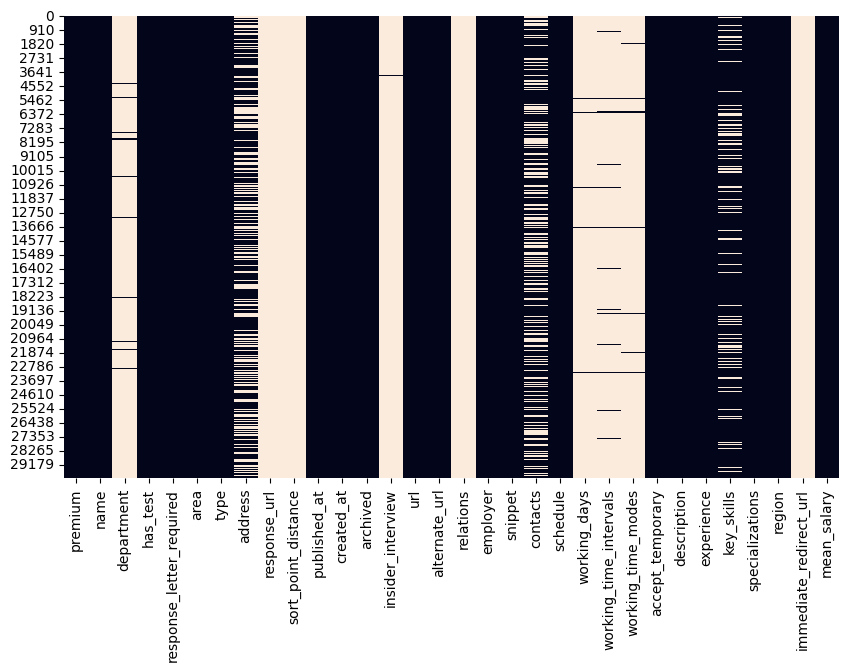

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isna(), cbar=False)
plt.show()

Удалим колонки, которые не заполнены более чем на 90%

In [15]:
lst_to_drop = list(missing[missing > 0.90].index)
# lst_to_drop = [l for l in lst_to_drop if l not in ['working_time_modes', 'working_days', 'working_time_intervals']]
lst_to_drop

['relations',
 'immediate_redirect_url',
 'response_url',
 'sort_point_distance',
 'insider_interview',
 'working_days',
 'working_time_modes',
 'department',
 'working_time_intervals']

Можно удалить еще следующие колонки, потому что больше 90% заполнены только False

In [16]:
# for col in df.columns:
#   if df[col].dtype =='bool':
#     print(df[col].value_counts(normalize=True)*100)
#     # print(df.groupby(df[col])['mean_salary'].mean()) - проверка на значимость пропущенной информации для целевой переменной
#     print('\n')
#     lst_to_drop.append(col)

### Числовые признаки

In [17]:
numeric_cols = [col for col in df.select_dtypes(include=np.number).columns if col not in lst_to_drop]
numeric_cols
# plt.figure(figsize=(10,8))
# sns.heatmap(df[numeric_cols].corr(), cmap="coolwarm", center=0)
# plt.title("Correlation matrix")
# plt.show()

['mean_salary']

Числовых признаков пока нет

### Категориальные признаки

In [18]:
df.groupby('experience')['mean_salary'].agg(["mean","median","count"])

,mean,median,count
experience,,,
"{'id': 'between1And3', 'name': 'От 1 года до 3 лет'}",82947.980515,60000.0,14729
"{'id': 'between3And6', 'name': 'От 3 до 6 лет'}",136930.573288,105000.0,6263
"{'id': 'moreThan6', 'name': 'Более 6 лет'}",184927.412747,150000.0,659
"{'id': 'noExperience', 'name': 'Нет опыта'}",87173.526857,50000.0,8359


Experience демонстрирует монотонный рост зарплаты $\rightarrow$ ordinal encoding оправдан.

In [19]:
df.groupby('schedule')['mean_salary'].agg(["mean","median","count"])

,mean,median,count
schedule,,,
"{'id': 'flexible', 'name': 'Гибкий график'}",112544.597215,92500.0,1939
"{'id': 'flyInFlyOut', 'name': 'Вахтовый метод'}",102165.095745,90000.0,94
"{'id': 'fullDay', 'name': 'Полный день'}",94231.335782,65000.0,22668
"{'id': 'remote', 'name': 'Удаленная работа'}",114905.803187,80000.0,4550
"{'id': 'shift', 'name': 'Сменный график'}",56920.743742,50000.0,759


### Текстовые признаки

Удалим все колонки с ссылками

In [20]:
url_cols = [x for x in df.columns if 'url' in x]
lst_to_drop = lst_to_drop + url_cols

Контакты не важны

In [21]:
lst_to_drop.append('contacts')

Все вакансии опубликованы в 2022, поэтому считаем, что сильной зависимости от дат нет. Удалим столбцы published_at и created_at

In [22]:
df['published_at'] = pd.to_datetime(df['published_at']).dt.to_period("Y")
df['published_at'].value_counts()

/var/folders/3z/h7_y2tw90bd9_d3j8sfghz_00000gn/T/ipykernel_7136/2260017115.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['published_at'] = pd.to_datetime(df['published_at']).dt.to_period("Y")


published_at
2022    30010
Freq: Y-DEC, Name: count, dtype: int64

In [23]:
lst_to_drop = lst_to_drop + ['created_at', 'published_at']

Удаление, потому что пока не понятно, что с ними можно делать

In [24]:
lst_to_drop = lst_to_drop + ['employer', 'snippet', 'description', 'specializations']

In [25]:
df.drop(lst_to_drop, axis=1, inplace=True)

Соберем все в одну функцию

In [26]:
def EDA (df, lst_to_drop):
    # df = df.drop_duplicates()
    df = df.replace('[]', np.nan)
    df['published_at'] = pd.to_datetime(df['published_at']).dt.to_period("Y")
    df.drop(lst_to_drop, axis=1, inplace=True)
    return df

# Feature engineering

### Обработка местоположения

In [27]:
df.loc[0, 'area']

"{'id': '2', 'name': 'Санкт-Петербург', 'url': 'https://api.hh.ru/areas/2'}"

По идее, это из таблицы городов и отсюда нужно только название, поэтому остальное удаляем.

In [28]:
import json

def extract_city(area_str):
    try:
        area_dict = json.loads(area_str.replace("'", '"'))  # заменяем одинарные кавычки на двойные для корректного JSON
        return area_dict.get('name')
    except:
        return None

# Применяем функцию
df['area'] = df['area'].apply(extract_city)
# df['area']

In [29]:
df['area'].value_counts()

area
Москва                                6188
Санкт-Петербург                       2893
Екатеринбург                          1056
Новосибирск                            951
Краснодар                              892
                                      ... 
Артемовский (Свердловская область)       1
Торжок                                   1
Кимовск                                  1
Путилково                                1
Тура (Красноярский край)                 1
Name: count, Length: 784, dtype: int64

Слишком много городов, оставим названия только самым крупным, а остальные разделим на категории по кол-ву вакансий

In [30]:
city_counts = df['area'].value_counts()

def categorize_city(city, city_counts):
    if city_counts.get(city, 0) > 1000:  # Крупные города
        return city
    elif city_counts.get(city, 0) > 100:   # Средние города
        return 'Средний город'
    else:                                  # Малые города
        return 'Маленький город'

df['city'] = df['area'].apply(lambda x: categorize_city(x, city_counts))
city_dict = dict(df[['area', 'city']].values)
df.drop(['area', 'region'], axis=1, inplace=True)
df['city'].value_counts()

city
Средний город      14107
Москва              6188
Маленький город     5766
Санкт-Петербург     2893
Екатеринбург        1056
Name: count, dtype: int64

Вряд ли адрес сильно влияет на зарплату, можно остановиться на городе, а адреса удалить

In [31]:
df.drop('address', axis=1, inplace=True)

Вместо городов будем сравнивать средние зарплаты по этому типу города

In [32]:
df.groupby('city')['mean_salary'].mean('mean_salary').values

array([ 93230.41808712,  68126.67421089, 134621.21081125, 114138.68562046,
        90407.50453675])

In [33]:
city_mean_salary_dict = dict(df.groupby('city')['mean_salary'].mean('mean_salary'))
df['city_mean_salary'] = df['city'].map(city_mean_salary_dict)
df[['city', 'city_mean_salary']]


,city,city_mean_salary
0,Санкт-Петербург,114138.685620
1,Маленький город,68126.674211
2,Средний город,90407.504537
3,Москва,134621.210811
4,Маленький город,68126.674211
...,...,...
30067,Москва,134621.210811
30068,Средний город,90407.504537
30069,Маленький город,68126.674211
30070,Екатеринбург,93230.418087


In [34]:
def calc_city_mean_salary(df):
    return dict(df.groupby('city')['mean_salary'].mean('mean_salary'))
df['city_mean_salary'] = df['city'].map(calc_city_mean_salary(df))

In [35]:
df.drop('city', axis=1, inplace=True)

Соберем все в одну функцию

In [36]:
def location(df, X_train, city_dict):
    df['area'] = df['area'].apply(extract_city)
    city_counts = df['area'].value_counts()
    df['city'] = df['area'].apply(lambda x: city_dict.get(x) or categorize_city(x, city_counts))
    df.drop(['area', 'region'], axis=1, inplace=True)

    df.drop('address', axis=1, inplace=True)

    df['city_mean_salary'] = df['city'].map(calc_city_mean_salary(X_train))
    df.drop('city', axis=1, inplace=True)
    return df


### Выделение нужного в JSON-массивах. Обработка колонок 'type', 'schedule', 'experience'.

Для оставшихся колонок в виде JSON-массивов с небольшим количеством категорий выделим нужную информацию и получим колонки с категориальными признаками. 

In [37]:
import json
df['type'] = df['type'].apply(lambda x: json.loads(x.replace("'", '"')).get('name'))
df['type'].value_counts()

type
Открытая     29963
Анонимная       47
Name: count, dtype: int64

In [38]:
df['is_open'] = df['type'].replace({"Открытая" : 1, "Анонимная" : 0}).astype(int)
df.drop('type', axis = 1, inplace = True)

/var/folders/3z/h7_y2tw90bd9_d3j8sfghz_00000gn/T/ipykernel_7136/1747803942.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['is_open'] = df['type'].replace({"Открытая" : 1, "Анонимная" : 0}).astype(int)


In [39]:
df['schedule'] = df['schedule'].apply(lambda x: json.loads(x.replace("'", '"')).get('name'))
df['schedule'].value_counts()

schedule
Полный день         22668
Удаленная работа     4550
Гибкий график        1939
Сменный график        759
Вахтовый метод         94
Name: count, dtype: int64

In [40]:
df['experience'] = df['experience'].apply(lambda x: json.loads(x.replace("'", '"')).get('name'))
df['experience'].value_counts()

experience
От 1 года до 3 лет    14729
Нет опыта              8359
От 3 до 6 лет          6263
Более 6 лет             659
Name: count, dtype: int64

Опыт можно четко расставить по шкале, поэтому заменим название категории на ее ранг. 

In [41]:
df['experience'] = df['experience'].replace({"Нет опыта" : 0, "От 1 года до 3 лет" : 1, "От 3 до 6 лет" : 2, "Более 6 лет" : 3})

/var/folders/3z/h7_y2tw90bd9_d3j8sfghz_00000gn/T/ipykernel_7136/3991379538.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['experience'] = df['experience'].replace({"Нет опыта" : 0, "От 1 года до 3 лет" : 1, "От 3 до 6 лет" : 2, "Более 6 лет" : 3})


Из employer оставим только name

In [42]:
import ast
# df['employer'] = df['employer'].apply(lambda x: ast.literal_eval(x)['name'])

Соберем все в одну функцию

In [43]:
def json_cols(df):
    df['type'] = df['type'].apply(lambda x: json.loads(x.replace("'", '"')).get('name'))
    df['is_open'] = df['type'].replace({"Открытая" : 1, "Анонимная" : 0, "Рекламная" : 1}).astype(int)
    df.drop('type', axis = 1, inplace = True)

    df['schedule'] = df['schedule'].apply(lambda x: json.loads(x.replace("'", '"')).get('name'))
    
    df['experience'] = df['experience'].apply(lambda x: json.loads(x.replace("'", '"')).get('name'))
    df['experience'].replace({"Нет опыта" : 0, "От 1 года до 3 лет" : 1, "От 3 до 6 лет" : 2, "Более 6 лет" : 3}, inplace=True)

    return df

### Обработка name с помощью эмбеддингов

Для получения векторных представлений (эмбеддингов) текстовых полей 'name' и 'employer' используем модель all-MiniLM-L6-v2.

In [44]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

In [45]:
embeddings_name = model.encode(df['name'].str.lower().replace(r'[\W_]+', ' ', regex=True).tolist()) # Приводим к нижнему регистру, заменяем небуквенно-цифровые символы на пробелы, преобразуем в список строк
print(embeddings_name.shape)

(30010, 384)


In [46]:
emb_df = pd.DataFrame(
    embeddings_name,
    columns=[f'name_emb_{i}' for i in range(embeddings_name.shape[1])]
)
df = pd.concat([df, emb_df], axis=1)

In [47]:
def name_with_emb(df):
    embeddings_name = model.encode(df['name'].str.lower().replace(r'[\W_]+', ' ', regex=True).tolist()) # Приводим к нижнему регистру, заменяем небуквенно-цифровые символы на пробелы, преобразуем в список строк
    emb_df = pd.DataFrame(embeddings_name, columns=[f'name_emb_{i}' for i in range(embeddings_name.shape[1])])
    df = pd.concat([df, emb_df], axis=1)
    return df

### Обработка key_skills

Попробую из key_skills составить массив навыков

In [48]:
def extract_key_skills(key_skills_list):
  if pd.isna(key_skills_list):
    return np.nan
  else:
    return [d['name'] for d in ast.literal_eval(key_skills_list)]

df['key_skills'] = df['key_skills'].apply(lambda x: extract_key_skills(x))

In [49]:
df['is_developer'] = df['name'].str.contains('программ|разраб|developer|dev', case=False)
df['is_data_analyst'] = df['name'].str.contains('data|scientist|analytics|аналитик|анализ|данн', case=False)
df['is_rieltor'] = df['name'].str.contains('риелтор|недвижимост|продаж', case=False)
df['is_lead'] = df['name'].str.contains('начальник|lead', case=False)
df['is_senior'] = df['name'].str.contains('ведущий|руководитель|senior|старший', case=False)

In [50]:
df.drop(['key_skills', 'name'], axis=1, inplace=True)

In [51]:
def extr_key_skills(df):
    df['key_skills'] = df['key_skills'].apply(lambda x: extract_key_skills(x))
    
    df['is_developer'] = df['name'].str.contains('программ|разраб|developer|dev', case=False)
    df['is_data_analyst'] = df['name'].str.contains('data|scientist|analytics|аналитик|анализ|данн', case=False)
    df['is_rieltor'] = df['name'].str.contains('риелтор|недвижимост|продаж', case=False)
    df['is_lead'] = df['name'].str.contains('начальник|lead', case=False)
    df['is_senior'] = df['name'].str.contains('ведущий|руководитель|senior|старший', case=False)

    df.drop(['key_skills', 'name'], axis=1, inplace=True)

    return df

### One-hot кодирование для категориальных признаков schedule

Далее преобразовываем категориальные признаки.

In [52]:
schedule_categories = ['schedule_' + x for x in str(df['schedule'].unique())]

In [53]:
schedule_dummies = pd.get_dummies(df['schedule'], prefix='schedule')
df = pd.concat([df, schedule_dummies], axis=1)
df.drop('schedule', axis=1, inplace=True)

In [54]:
def schedule_one_hot(df, schedule_cats=None):

    # Для schedule
    schedule_dummies = pd.get_dummies(df['schedule'], prefix='schedule')
    if schedule_cats is not None:
        # Добавляем отсутствующие колонки
        for col_name in schedule_cats:
            if col_name not in schedule_dummies.columns:
                schedule_dummies[col_name] = 0
        # # Упорядочиваем колонки
        # schedule_dummies = schedule_dummies.reindex(columns=[f'schedule_{cat}' for cat in schedule_cats], fill_value=0)
    
    df = pd.concat([df, schedule_dummies], axis=1)
    df.drop('schedule', axis=1, inplace=True)
    return df


In [55]:
df

,premium,has_test,response_letter_required,archived,accept_temporary,experience,mean_salary,city_mean_salary,is_open,name_emb_0,...,is_developer,is_data_analyst,is_rieltor,is_lead,is_senior,schedule_Вахтовый метод,schedule_Гибкий график,schedule_Полный день,schedule_Сменный график,schedule_Удаленная работа
0,False,False,False,False,False,0.0,125000.0,114138.685620,1.0,-0.021850,...,False,False,True,False,False,False,True,False,False,False
1,False,False,False,False,False,1.0,50000.0,68126.674211,1.0,-0.004469,...,False,False,False,False,False,True,False,False,False,False
2,False,False,False,False,False,1.0,80000.0,90407.504537,1.0,0.056179,...,True,False,False,False,True,False,False,True,False,False
3,False,False,False,False,False,1.0,120000.0,134621.210811,1.0,0.041678,...,False,False,False,False,False,False,False,True,False,False
4,False,False,False,False,False,1.0,15000.0,68126.674211,1.0,0.065373,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28882,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.022524,...,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False
29135,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.016186,...,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False
29276,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.016195,...,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False
29305,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.002352,...,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False


In [56]:
def prepare_features(X, X_train):
    X = EDA(X, lst_to_drop)
    X = location(X, X_train, city_dict)
    X = json_cols(X)
    X = name_with_emb(X)
    X = extr_key_skills(X)
    X = schedule_one_hot(X, schedule_categories)
    return X

# ML

### Подготовка данных

In [57]:
from sklearn.model_selection import train_test_split

df = pd.read_csv(f"{download_path}/train_contest.csv")
X_train, X_test, y_train, y_test = train_test_split(df.drop(['mean_salary'], axis=1), df['mean_salary'], test_size=0.2, random_state=42)


In [58]:
def pred_cols_coincedence(X_train, X_pred):
    '''
    Проверка, что колонки совпадают с тренировочным набором
    Добавление отсутствующих колонок
    ---
    Returns
    X_pred - обновленный с правильными колонками
    '''

    train_cols = set(X_train.columns)
    test_cols = set(X_pred.columns)

    for col in train_cols - test_cols:
        X_pred[col] = 0
        print(col)

    for col in test_cols - train_cols:
        X_pred.drop(col, axis=1, inplace=True)

    # Упорядочивание колонок как в тренировочном наборе
    train_cols_order = X_train.columns.tolist()
    return X_pred[train_cols_order]

In [59]:
X_train = prepare_features(X_train, X_train)
X_test = prepare_features(X_test, X_train)

X_test = pred_cols_coincedence(X_train, X_test)

/var/folders/3z/h7_y2tw90bd9_d3j8sfghz_00000gn/T/ipykernel_7136/187302626.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace('[]', np.nan)
/var/folders/3z/h7_y2tw90bd9_d3j8sfghz_00000gn/T/ipykernel_7136/187302626.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['published_at'] = pd.to_datetime(df['published_at']).dt.to_period("Y")


KeyError: 'city'

In [ ]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test) 

### Базовая модель: линейная регрессия

In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24057 entries, 0 to 24056
Columns: 402 entries, premium to schedule_Удаленная работа
dtypes: bool(15), float32(384), float64(1), int64(2)
memory usage: 36.1 MB


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

base_reg = LinearRegression().fit(X_train, y_train_log)
print('MAE score: ', mean_absolute_error(y_test_log, base_reg.predict(X_test)))

MAE score:  0.37160061664356236


### XGBRegressor

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

# parameters = {
#     'n_estimators': [50, 100],
#     'max_depth': [3, 4, 5],
#     'learning_rate': [0.01, 0.1],
#     'min_child_weight': [1, 3, 5],
#     'subsample': [0.6, 0.8, 1.0],
#     'colsample_bytree': [0.6, 1.0],
#     'gamma': [0, 0.1, 0.2]
# }

# XGBR = XGBRegressor(random_state=42)

# grid_search = GridSearchCV(
#     estimator=XGBR,
#     param_grid=parameters,
#     scoring='neg_mean_absolute_error',
#     n_jobs=-1,
#     verbose=1,
#     refit=True
# )
# grid_search.fit(X_train, y_train)

# print(f"Лучшие параметры: {grid_search.best_params_}")

In [ ]:
XGBR = XGBRegressor(random_state=42, colsample_bytree=0.6, gamma=0, learning_rate=0.1, max_depth=5, min_child_weight=5, n_estimators=100, subsample=0.8).fit(X_train, y_train_log)
print('MAE score: ', mean_absolute_error(y_test_log, XGBR.predict(X_test)))

MAE score:  0.3284565842708664


## Предсказание

In [ ]:
df = pd.read_csv(f"{download_path}/train_contest.csv")
df_pred = pd.read_csv(download_path + "/for_prediction.csv")

X = df.drop('mean_salary', axis=1)
y_log = np.log1p(df['mean_salary'])

X_pred = df_pred.drop('Id', axis=1)

X = prepare_features(X)
X_pred = prepare_features(X_pred)

X_pred = pred_cols_coincedence(X, X_pred)

/var/folders/3z/h7_y2tw90bd9_d3j8sfghz_00000gn/T/ipykernel_5670/187302626.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace('[]', np.nan)
/var/folders/3z/h7_y2tw90bd9_d3j8sfghz_00000gn/T/ipykernel_5670/187302626.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['published_at'] = pd.to_datetime(df['published_at']).dt.to_period("Y")
/var/folders/3z/h7_y2tw90bd9_d3j8sfghz_00000gn/T/ipykernel_5670/2593926138.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['i

In [ ]:
base_reg = LinearRegression().fit(X, y_log)

prediction_log = base_reg.predict(X_pred)
prediction = np.expm1(prediction_log) 
submission = pd.DataFrame({
    'Id': df_pred['Id'],
    'Predicted': prediction
})

# submission.to_csv('submission_XGBR.csv', index=False)

In [ ]:
XGBR = XGBRegressor(random_state=42, colsample_bytree=0.6, gamma=0, learning_rate=0.1, max_depth=5, min_child_weight=5, n_estimators=100, subsample=0.8).fit(X, y_log)

prediction_log = XGBR.predict(X_pred)
prediction = np.expm1(prediction_log) 
submission = pd.DataFrame({
    'Id': df_pred['Id'],
    'Predicted': prediction
})

# submission.to_csv('submission_XGBR.csv', index=False)

# A/B-эксперимент

#### Матрицы признаков

In [ ]:
df = pd.read_csv(f"{download_path}/train_contest.csv")

X = df.drop('mean_salary', axis=1)
X = prepare_features(X, X)

y_log = np.log1p(df['mean_salary'])

feature_cols = X.columns

baseline_features = ['premium', 'has_test', 'response_letter_required', 'archived', 'accept_temporary', 'experience', 'city_mean_salary', 'is_open']
extended_features = feature_cols.tolist()

X_A = X[baseline_features]
X_B = X[extended_features]

print("Baseline features:", len(X_A.columns))
print("Extended features:", len(X_B.columns))

/var/folders/3z/h7_y2tw90bd9_d3j8sfghz_00000gn/T/ipykernel_5670/187302626.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace('[]', np.nan)
/var/folders/3z/h7_y2tw90bd9_d3j8sfghz_00000gn/T/ipykernel_5670/187302626.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['published_at'] = pd.to_datetime(df['published_at']).dt.to_period("Y")
/var/folders/3z/h7_y2tw90bd9_d3j8sfghz_00000gn/T/ipykernel_5670/2593926138.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['i

Baseline features: 8
Extended features: 402


#### KFold оценка

In [ ]:
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error

kf = KFold(n_splits=5, shuffle=True, random_state=42)

mae_A = []
mae_B = []

for train_idx, val_idx in kf.split(X_A):
    
    X_train_A, X_val_A = X_A.iloc[train_idx], X_A.iloc[val_idx]
    X_train_B, X_val_B = X_B.iloc[train_idx], X_B.iloc[val_idx]
    
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model_A = Ridge()
    model_B = Ridge()
    
    model_A.fit(X_train_A, y_train)
    model_B.fit(X_train_B, y_train)
    
    pred_A = model_A.predict(X_val_A)
    pred_B = model_B.predict(X_val_B)
    
    mae_A.append(mean_absolute_error(y_val, pred_A))
    mae_B.append(mean_absolute_error(y_val, pred_B))

mae_A = np.array(mae_A)
mae_B = np.array(mae_B)

print("MAE Baseline:", mae_A)
print("MAE Extended:", mae_B)

MAE Baseline: [0.53091096 0.53681287 0.54607745 0.53846272 0.54195244]
MAE Extended: [0.37059192 0.36567832 0.37105712 0.36084937 0.36612209]


#### Разница качества

In [ ]:
diff = mae_A - mae_B

print("Mean improvement:", diff.mean())
print("Std improvement:", diff.std())

Mean improvement: 0.17198352443677828
Std improvement: 0.006204779033616471


#### Bootstrap доверительный интервал

In [ ]:
def bootstrap_ci(data, n_boot=10000, alpha=0.05):
    boot_means = []
    for _ in range(n_boot):
        sample = np.random.choice(data, size=len(data), replace=True)
        boot_means.append(sample.mean())
        
    lower = np.percentile(boot_means, 100 * alpha/2)
    upper = np.percentile(boot_means, 100 * (1 - alpha/2))
    
    return lower, upper

ci_lower, ci_upper = bootstrap_ci(diff)

print(f"95% CI for improvement: {ci_lower:.4f}, {ci_upper:.4f}")

95% CI for improvement: 0.1659, 0.1764


#### Статистическая проверка (парный тест)

In [ ]:
from scipy.stats import ttest_rel

t_stat, p_value = ttest_rel(mae_A, mae_B)

print("t-stat:", t_stat)
print("p-value:", p_value)

t-stat: 55.43582567727226
p-value: 6.339392230397496e-07


#### Интерпретация результатов

In [ ]:
print(f'''- Среднее улучшение MAE: {diff.mean():.3f}
- 95% доверительный интервал: [{ci_lower:.4f}, {ci_upper:.4f}]
- p-value: {p_value*1e+6:.4f}e-06

Интерпретация:  
- CI полностью > 0   
- p-value < 0.05  

Значит, Feature engineering статистически значимо улучшает модель.''')

- Среднее улучшение MAE: 0.172
- 95% доверительный интервал: [0.1659, 0.1764]
- p-value: 0.6339e-06

**Интерпретация:**  
- CI полностью > 0   
- p-value < 0.05  
ightarrow$ Feature engineering статистически значимо улучшает модель.
